In [1]:
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import r2_score
import seaborn as sns
import scipy.stats as st
import scanpy as sc
import anndata as ad
import pandas as pd
import emb_gwas as eg
import numpy as np
from tqdm import tqdm
import pylab as pl
from scipy import stats
import os
from os.path import join, dirname
import glob
import matplotlib.pyplot as plt
import numpy as np

/home/aih/shubham.chaudhary/miniconda3/envs/milgan/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/home/aih/shubham.chaudhary/miniconda3/envs/milgan/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


In [2]:
tissue_colors = {
    'Esophagus_Muscularis': 'lightseagreen',
    'Esophagus_Mucosa': 'mediumaquamarine',
    'Colon_Transverse': 'lightpink',
    'Stomach': 'palevioletred',
    'Skin_Sun_Exposed_Lower_leg': '#D8BFD8',
    'Breast_Mammary_Tissue': 'rosybrown',
    'Thyroid': '#FFDAB9',
    'Adipose_Subcutaneous': '#ADD8E6',
    'Muscle_Skeletal': 'lightsalmon',
    'Artery_Tibial': 'darkorange',
    'Nerve_Tibial': 'orangered',
}

In [ ]:
# Reading the gene prediction file
method_colors = {
    'retccl': 'palevioletred',
    'simclr': 'lightseagreen',
    'kimiaNet': 'mediumaquamarine',
    'plip': 'lightsalmon',
    'Autoencoder': 'orangered',
}
model_type = [
    'retccl',
    'simclr',
    'kimiaNet',
    'plip',
    'Autoencoder',
    
]
tissue_list = [
    'Breast_Mammary_Tissue',
    'Adipose_Subcutaneous',
    'Colon_Transverse',
    'Artery_Tibial',
    'Stomach',
    'Esophagus_Mucosa',
    'Esophagus_Muscularis',
    'Muscle_Skeletal',
     'Nerve_Tibial',
    'Skin_Sun_Exposed_Lower_leg',
    'Thyroid',
]

outdir = '/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/stage8/gene_prediction/all_v1/plots'
df_all = []
for tissue in tissue_list:
    for model_type_ in model_type:
        path = f'/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/stage7/gene_prediction/{tissue}_{model_type_}_None_*.csv'
        file_list = glob.glob(path)
        for file in file_list:
            _ = file.split('/')[-1].split('_None')[0].split('_')
            df = pd.read_csv(file)
            df['tissue'] = tissue
            df['color'] = method_colors[model_type_]
            df['model_type'] = model_type_
            df_all.append(df)

In [4]:
df_all = pd.concat(df_all, axis=0)

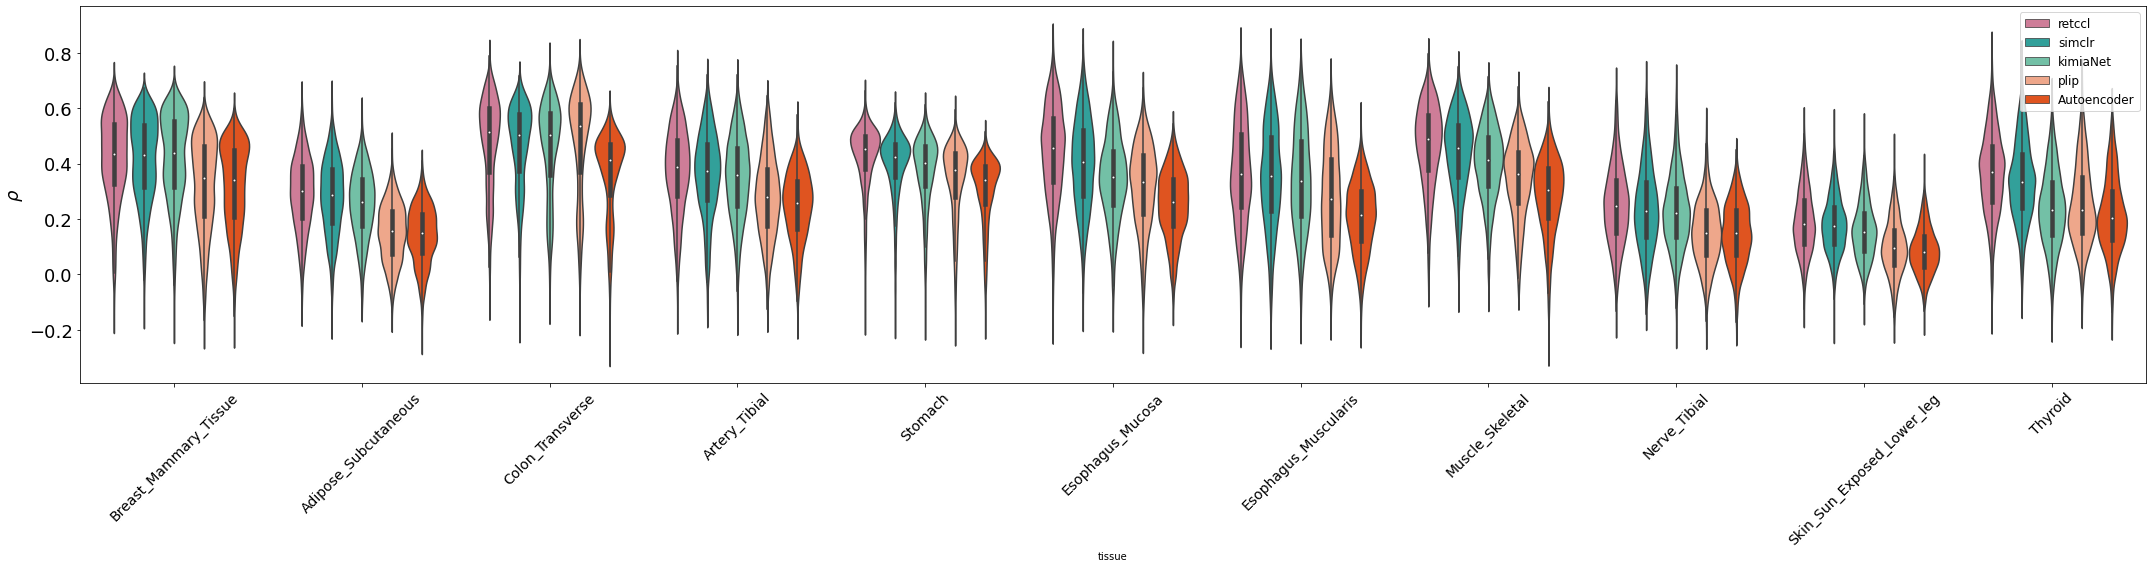

In [19]:
path = '/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/supplementary/supplementaryFigure_1'
outfile = join(path, f'allTissue_gene_prediction_violin_plot_rho.png')
os.makedirs(dirname(outfile), exist_ok=True)

pl.figure(1, figsize=(30, 8))
custom_palette = [method_colors[model_type] for model_type in df_tissue['model_type'].unique()]

ax = pl.subplot(1, 1, 1)
sns.violinplot(data=df_all, x='tissue', y='correlation',hue='model_type', palette=custom_palette, ax=ax, fontsize=14)

# Change x-axis and y-axis font
ax.set_xticklabels(ax.get_xticklabels(), fontdict={'fontsize': 14}, rotation=45)
# ax.set_yticklabels(ax.get_yticklabels(), fontdict={'fontsize': 12})
ax.set_ylabel(r'$\rho$', fontsize=18)
# plt.xlabel(r'$\rho$ (distance)')

# Change y-axis label font size
ax.tick_params(axis='y', labelsize=18)

# Remove the legend
ax.legend(fontsize=12, loc='best')

pl.tight_layout()
pl.savefig(outfile, dpi=300)